# Explaining Forest Cover Type Predictions with LIME

## Aim

This notebook trains an XGBoost classifier to predict forest cover type from cartographic and environmental measurements, evaluates it on held-out data, and uses **LIME Tabular** to explain individual predictions. It uses one XAI method throughout: LIME’s tabular classifier explainer.

The original Covertype dataset has 581,012 observations, 54 input features, and 7 target classes. To keep training and explanation runs practical on a laptop, the modeling workflow takes a reproducible, stratified sample of 10,000 records from the full dataset.


## 1. Imports and reproducibility

We fix seeds for the data sample, train/test split, XGBoost model, and LIME sampling. The first data-loading run may fetch the Covertype dataset through scikit-learn if it is not already cached.


In [28]:
from time import perf_counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, precision_recall_fscore_support
)
from xgboost import XGBClassifier
from lime.lime_tabular import LimeTabularExplainer

RANDOM_STATE = 42
SAMPLE_SIZE = 10_000
plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (9, 5)
%matplotlib inline


## 2. Dataset and prediction objective

The **Covertype** dataset describes forest areas in the Roosevelt National Forest of northern Colorado. Each row represents a 30 × 30 metre cell. The objective is to predict its forest cover type from the cartographic variables. The dataset was assembled for predicting cover type from variables available from a US Geological Survey (USGS) and US Forest Service (USFS) digital map.

### Target classes

The original labels 1–7 identify: Spruce/Fir, Lodgepole Pine, Ponderosa Pine, Cottonwood/Willow, Aspen, Douglas-fir, and Krummholz. The code remaps them to 0–6 for XGBoost while retaining these names in reports and plots.

### Input features

There are 54 features:

| Feature group | Features | What they represent |
|---|---|---|
| Elevation | `Elevation` | Elevation in metres |
| Terrain | `Aspect`, `Slope` | Aspect in degrees azimuth and slope in degrees |
| Hydrology | `Horizontal_Distance_To_Hydrology`, `Vertical_Distance_To_Hydrology` | Horizontal and vertical distance to surface water |
| Access / fire | `Horizontal_Distance_To_Roadways`, `Horizontal_Distance_To_Fire_Points` | Horizontal distance to roads and fire ignition points |
| Hillshade | `Hillshade_9am`, `Hillshade_Noon`, `Hillshade_3pm` | Modelled hillshade at 9 a.m., noon, and 3 p.m. (0–255) |
| Wilderness area | `Wilderness_Area_0`–`Wilderness_Area_3` | Four binary indicators for wilderness areas |
| Soil type | `Soil_Type_0`–`Soil_Type_39` | Forty binary indicators for soil types |

The four wilderness indicators and forty soil indicators are one-hot / binary features. Distances and elevation are measured in metres; aspect and slope are angular measurements.

### Dataset source

The notebook loads Covertype with `sklearn.datasets.fetch_covtype()`. Scikit-learn uses its own dataset cache and fetches the data automatically if it is not cached; no project-local dataset archive is required.


In [29]:
from sklearn.datasets import fetch_covtype
import sys
from pathlib import Path

for _directory in (Path.cwd(), Path.cwd() / "XAI" / "experiments", Path.cwd() / "experiments"):
    if (_directory / "controlled_lime_protocol.py").is_file():
        sys.path.insert(0, str(_directory))
        break
else:
    raise FileNotFoundError("Keep controlled_lime_protocol.py beside the experiment notebooks.")

from controlled_lime_protocol import CLASS_NAMES, load_controlled_covtype

covtype = fetch_covtype()
X, y, X_train, X_test, y_train, y_test = load_controlled_covtype()
feature_names = X.columns.tolist()
full_dataset_rows = len(covtype.data)

class_names = list(CLASS_NAMES)

print("Loaded Covertype with sklearn.datasets.fetch_covtype().")
print()
print(f"Full dataset rows: {full_dataset_rows:,}")
print(f"Modeling sample rows: {len(X):,} | Features: {X.shape[1]} | Classes: {len(class_names)}")
display(X.head())


Loaded Covertype with sklearn.datasets.fetch_covtype().

Full dataset rows: 581,012
Modeling sample rows: 10,000 | Features: 54 | Classes: 7


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type_30,Soil_Type_31,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39
0,2770.0,101.0,11.0,300.0,14.0,808.0,239.0,225.0,115.0,543.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,3083.0,104.0,10.0,67.0,0.0,3006.0,238.0,227.0,119.0,5627.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2531.0,156.0,20.0,30.0,-9.0,1571.0,238.0,238.0,119.0,1443.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2457.0,275.0,17.0,234.0,64.0,391.0,172.0,242.0,208.0,1342.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,3046.0,34.0,14.0,960.0,227.0,1208.0,217.0,207.0,122.0,2462.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Class counts in the modeling sample

The full dataset is imbalanced: some forest types occur much more often than others. This plot shows class counts in our 10,000-row stratified sample. We also stratify the train/test split so each subset retains similar class proportions.


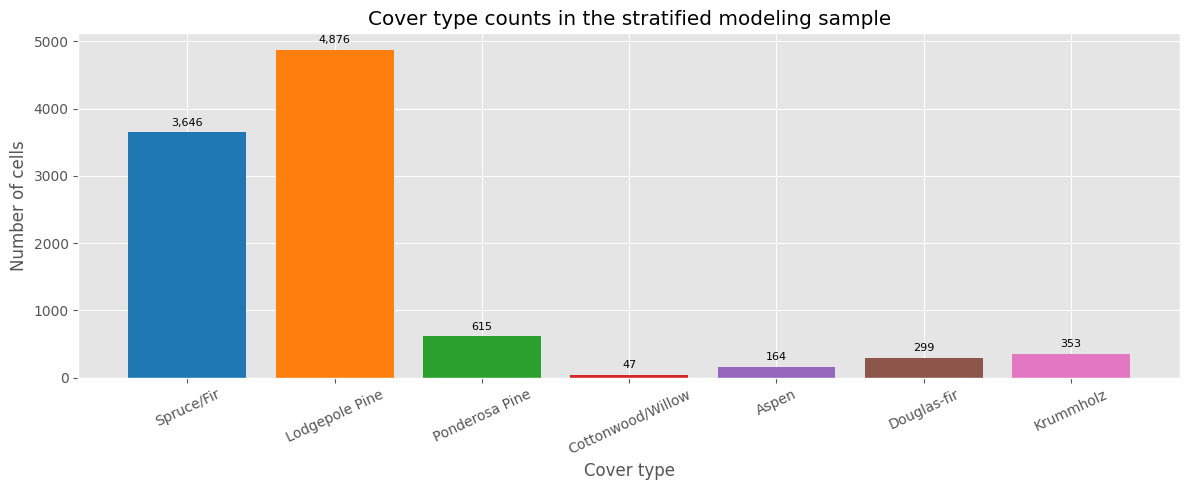

In [30]:
class_counts = y.map(lambda class_id: class_names[class_id]).value_counts().reindex(class_names)
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(class_counts.index, class_counts.values, color=plt.cm.tab10(np.arange(len(class_names))))
ax.set(title="Cover type counts in the stratified modeling sample", xlabel="Cover type", ylabel="Number of cells")
ax.tick_params(axis="x", labelrotation=25)
for bar, value in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 100, f"{value:,}", ha="center", fontsize=8)
plt.tight_layout()
plt.show()


### Continuous feature distributions

The first ten features are continuous measurements and use different scales. We standardize them **for this plot only** so the distributions can be compared; XGBoost is trained on the original values. Boxplots show how these measurements vary across cover types.


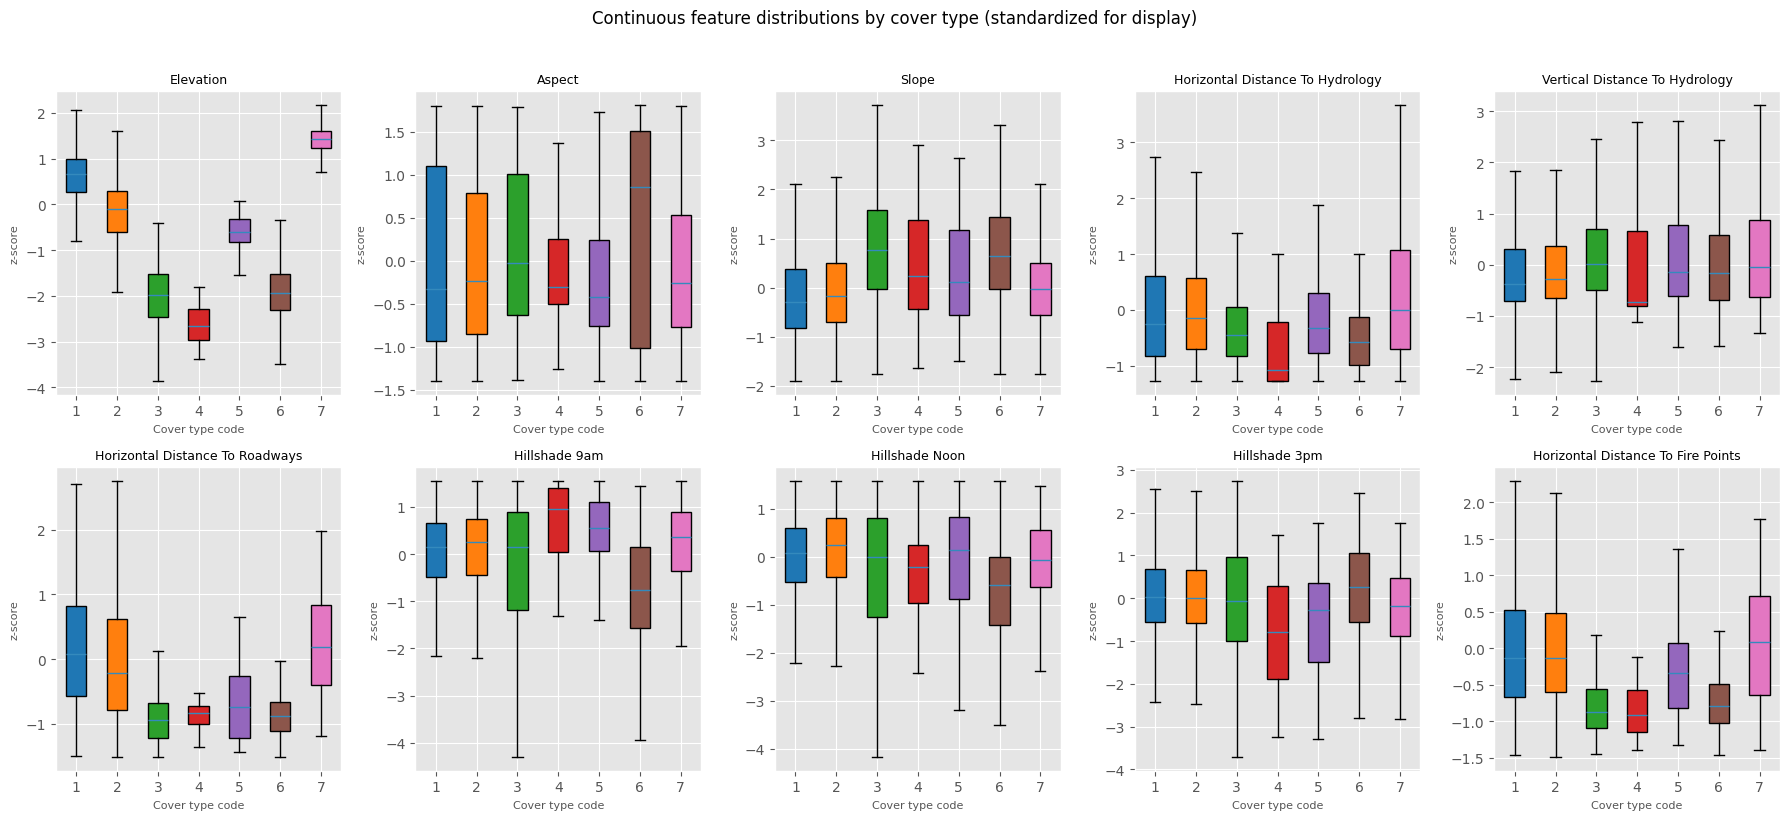

In [4]:
continuous_features = feature_names[:10]
X_cont = X[continuous_features]
z = (X_cont - X_cont.mean()) / X_cont.std(ddof=0)
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
class_colors = plt.cm.tab10(np.arange(len(class_names)))
for ax, feature in zip(axes.flat, continuous_features):
    grouped = [z.loc[y == class_id, feature].to_numpy() for class_id in range(len(class_names))]
    bp = ax.boxplot(grouped, patch_artist=True, showfliers=False)
    for patch, color in zip(bp["boxes"], class_colors):
        patch.set_facecolor(color)
    ax.set_title(feature.replace("_", " "), fontsize=9)
    ax.set_xticks(range(1, len(class_names) + 1), labels=range(1, len(class_names) + 1))
    ax.set_xlabel("Cover type code", fontsize=8)
    ax.set_ylabel("z-score", fontsize=8)
fig.suptitle("Continuous feature distributions by cover type (standardized for display)", y=1.02)
plt.tight_layout()
plt.show()


### Wilderness and soil indicator prevalence

This heatmap shows the share of observations in each cover type with each binary area/soil indicator set to 1. It helps show which soil and wilderness indicators are more common within each class. These are associations in this dataset, not causal effects.


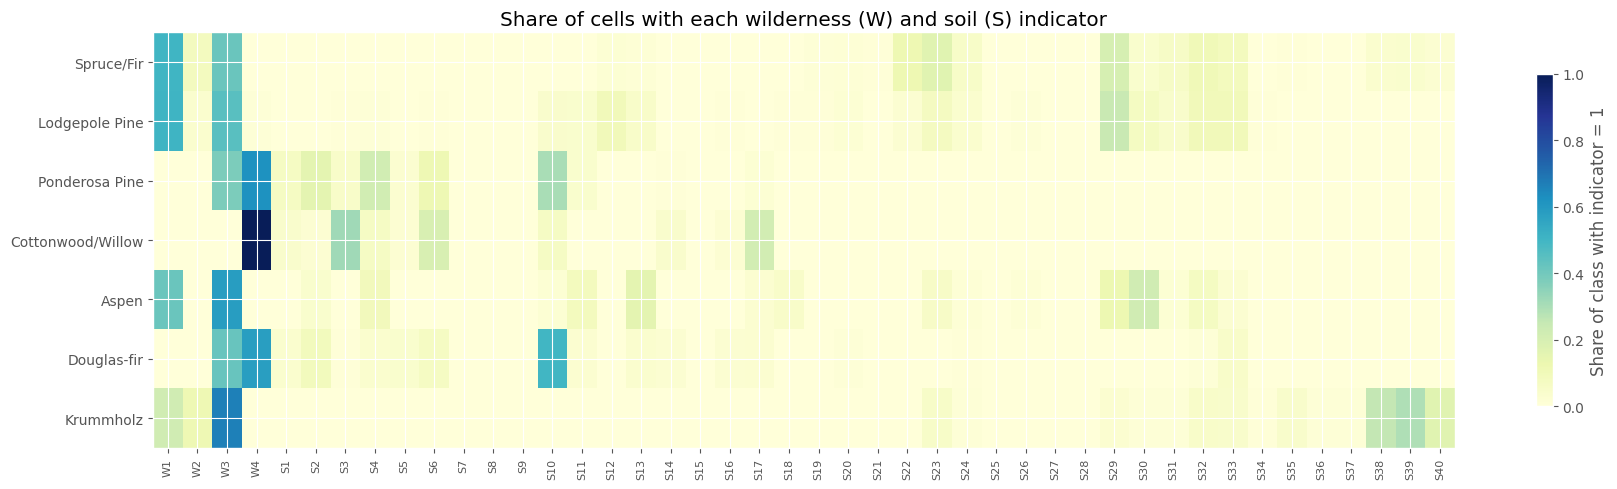

In [5]:
indicator_features = feature_names[10:]
prevalence = X.assign(cover_type=y).groupby("cover_type")[indicator_features].mean().reindex(range(len(class_names)))
fig, ax = plt.subplots(figsize=(18, 5))
image = ax.imshow(prevalence.to_numpy(), aspect="auto", cmap="YlGnBu", vmin=0, vmax=1)
ax.set_yticks(range(len(class_names)), labels=class_names)
short_names = [f"W{i}" for i in range(1, 5)] + [f"S{i}" for i in range(1, 41)]
ax.set_xticks(range(len(indicator_features)), labels=short_names, rotation=90, fontsize=8)
ax.set_title("Share of cells with each wilderness (W) and soil (S) indicator")
fig.colorbar(image, ax=ax, label="Share of class with indicator = 1", shrink=0.8)
plt.tight_layout()
plt.show()


### Pairwise Pearson correlations between continuous features

The heatmap compares the ten continuous measurements pair by pair. Pearson correlation ranges from −1 to +1 and describes linear association. Correlation does not establish causation; the binary soil and wilderness indicators are left out of this particular plot.


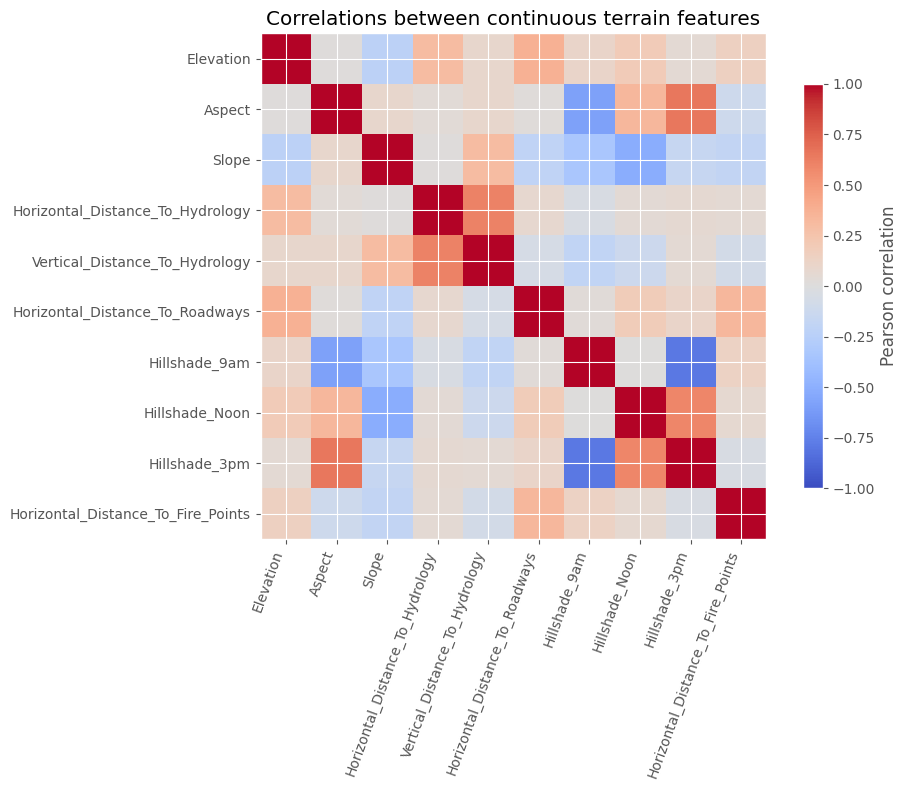

In [6]:
corr = X[continuous_features].corr()
fig, ax = plt.subplots(figsize=(10, 8))
image = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)), labels=corr.columns, rotation=70, ha="right")
ax.set_yticks(range(len(corr.index)), labels=corr.index)
fig.colorbar(image, ax=ax, label="Pearson correlation", shrink=0.8)
ax.set_title("Correlations between continuous terrain features")
plt.tight_layout()
plt.show()


## 3. Split the data and train XGBoost

We reserve 20% of the 10,000-row sample as a final test set. XGBoost is a gradient-boosted tree classifier suited to mixed numeric and binary tabular features. LIME is model-agnostic and can explain its class probabilities. The test set is not used to fit the model.


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

model = XGBClassifier(
    n_estimators=250,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="multi:softprob",
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=4,
)
model.fit(X_train, y_train)

print(f"Training rows: {len(X_train):,} | Test rows: {len(X_test):,}")
print("Training class proportions:")
print(y_train.value_counts(normalize=True).sort_index().rename(index=dict(enumerate(class_names))).round(3))
print("\nTest class proportions:")
print(y_test.value_counts(normalize=True).sort_index().rename(index=dict(enumerate(class_names))).round(3))


Training rows: 8,000 | Test rows: 2,000
Training class proportions:
cover_type
Spruce/Fir           0.365
Lodgepole Pine       0.488
Ponderosa Pine       0.062
Cottonwood/Willow    0.005
Aspen                0.016
Douglas-fir          0.030
Krummholz            0.035
Name: proportion, dtype: float64

Test class proportions:
cover_type
Spruce/Fir           0.364
Lodgepole Pine       0.488
Ponderosa Pine       0.062
Cottonwood/Willow    0.004
Aspen                0.016
Douglas-fir          0.030
Krummholz            0.036
Name: proportion, dtype: float64


## 4. Check XGBoost general performance

Five-fold cross-validation estimates consistency across several train/validation partitions of the training split. We then report metrics on the untouched test split. Because the classes are imbalanced, inspect precision, recall, and F1 for each class in addition to accuracy. Macro F1 gives each cover type equal weight; weighted F1 reflects class frequency.


In [8]:
model_params = dict(
    n_estimators=250, max_depth=6, learning_rate=0.1,
    subsample=0.9, colsample_bytree=0.9,
    objective="multi:softprob", eval_metric="mlogloss",
    tree_method="hist", random_state=RANDOM_STATE, n_jobs=4,
)
cv_scores = cross_val_score(
    XGBClassifier(**model_params), X_train, y_train, cv=5, scoring="accuracy", n_jobs=1
)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

print(f"5-fold training CV accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print(f"Held-out test accuracy:      {accuracy_score(y_test, y_pred):.3f}\n")
print(classification_report(y_test, y_pred, labels=np.arange(len(class_names)), target_names=class_names, digits=3, zero_division=0))


5-fold training CV accuracy: 0.797 ± 0.014
Held-out test accuracy:      0.797

                   precision    recall  f1-score   support

       Spruce/Fir      0.785     0.801     0.793       729
   Lodgepole Pine      0.819     0.836     0.827       975
   Ponderosa Pine      0.780     0.837     0.808       123
Cottonwood/Willow      0.600     0.667     0.632         9
            Aspen      0.571     0.242     0.340        33
      Douglas-fir      0.651     0.467     0.544        60
        Krummholz      0.823     0.718     0.767        71

         accuracy                          0.797      2000
        macro avg      0.719     0.653     0.673      2000
     weighted avg      0.794     0.797     0.794      2000



### Confusion matrix

Rows show the true cover type and columns show predictions. The diagonal contains correct classifications. Off-diagonal cells show which forest types the model confused.


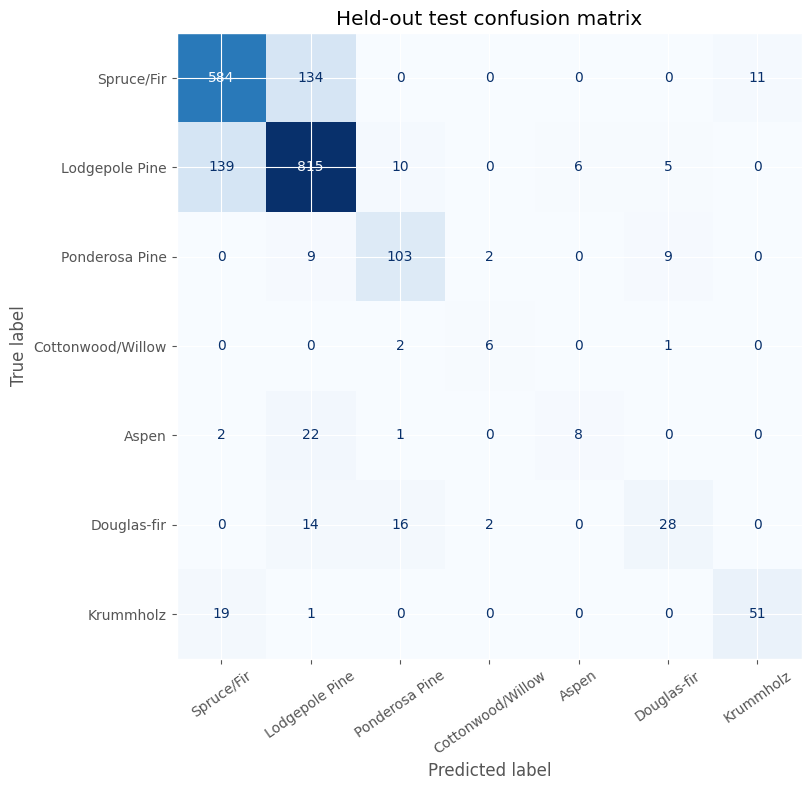

In [9]:
cm = confusion_matrix(y_test, y_pred, labels=np.arange(len(class_names)))
fig, ax = plt.subplots(figsize=(10, 8))
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
cm_display.plot(ax=ax, cmap="Blues", values_format=",d", colorbar=False, xticks_rotation=35)
plt.title("Held-out test confusion matrix")
plt.tight_layout()
plt.show()


### Per-class precision, recall, and F1

This grouped bar chart compares class-wise precision, recall, and F1 on the same held-out predictions. A class with lower recall is often being missed; lower precision means predictions of that class are more often wrong.


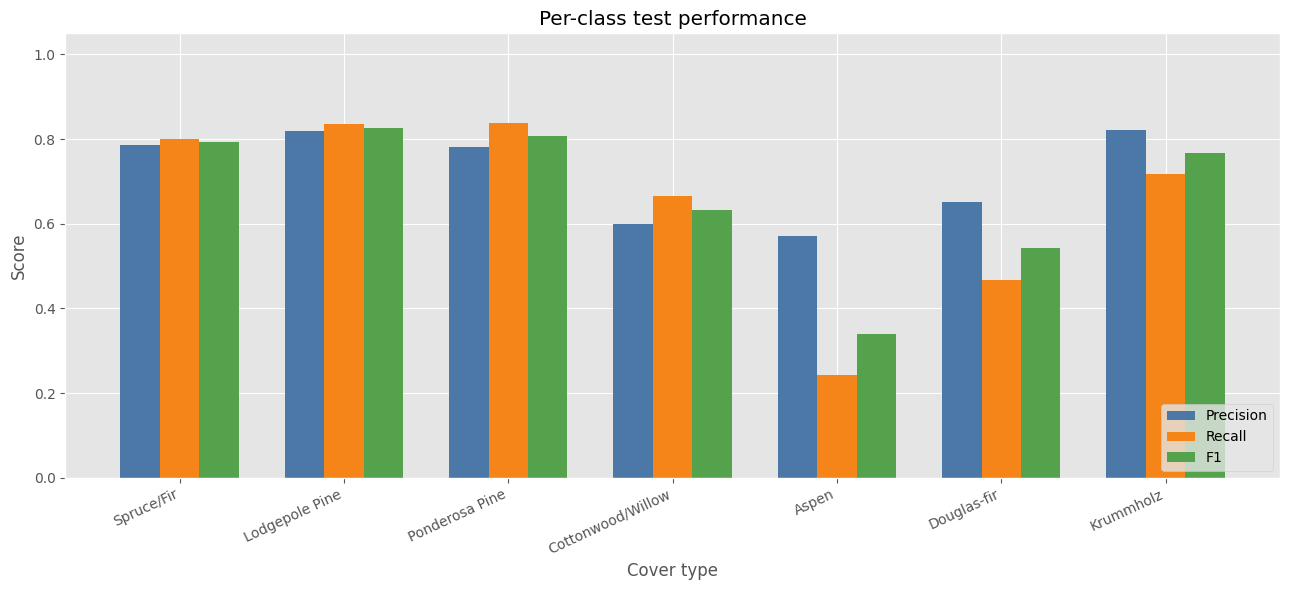

,Precision,Recall,F1
Spruce/Fir,0.785,0.801,0.793
Lodgepole Pine,0.819,0.836,0.827
Ponderosa Pine,0.780,0.837,0.808
Cottonwood/Willow,0.600,0.667,0.632
Aspen,0.571,0.242,0.340
Douglas-fir,0.651,0.467,0.544
Krummholz,0.823,0.718,0.767


In [10]:
precision, recall, f1, support = precision_recall_fscore_support(
    y_test, y_pred, labels=np.arange(len(class_names)), zero_division=0
)
metrics = pd.DataFrame({"Precision": precision, "Recall": recall, "F1": f1}, index=class_names)
fig, ax = plt.subplots(figsize=(13, 6))
positions = np.arange(len(class_names))
width = 0.24
for offset, (metric_name, color) in enumerate(zip(metrics.columns, ["#4C78A8", "#F58518", "#54A24B"])):
    ax.bar(positions + (offset - 1) * width, metrics[metric_name], width, label=metric_name, color=color)
ax.set(title="Per-class test performance", xlabel="Cover type", ylabel="Score", ylim=(0, 1.05))
ax.set_xticks(positions, labels=class_names, rotation=25, ha="right")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()
display(metrics.round(3))


## 5. Configure LIME Tabular

LIME explains one prediction at a time. It creates perturbed versions of an observation, queries XGBoost, and fits a simple local surrogate model. The feature weights describe local associations with the selected class; they are not causal effects or a global summary of XGBoost.

The explainer uses the training data as its reference distribution, with the 54 original feature names. Continuous features are discretized into ranges; the 44 binary indicators are explicitly marked as categorical so LIME can display them as present/absent. We also time explainer setup separately from explanation calls.


In [11]:
categorical_features = list(range(10, 54))
categorical_names = {i: ["0 (absent)", "1 (present)"] for i in categorical_features}

_explainer_start = perf_counter()
explainer = LimeTabularExplainer(
    training_data=X_train.to_numpy(),
    feature_names=list(X.columns),
    categorical_features=categorical_features,
    categorical_names=categorical_names,
    class_names=class_names,
    mode="classification",
    discretize_continuous=True,
    random_state=RANDOM_STATE,
)
explainer_setup_seconds = perf_counter() - _explainer_start
print(f"LIME explainer setup: {explainer_setup_seconds:.3f}s")

from itertools import combinations
from scipy.stats import spearmanr

LIME_SAMPLE_BUDGETS = [500, 1_000, 2_500, 5_000, 10_000]
STABILITY_REPEATS = 5
LIME_NUM_FEATURES = 10


LIME explainer setup: 0.058s


## 6. Benchmark runtime, stability, and local fidelity

We select a correctly classified, high-confidence held-out observation when one exists. For that same row and predicted class, the benchmark generates five explanations at each sample budget (500, 1,000, 2,500, 5,000, and 10,000). It records the duration of each LIME call and `exp.score` for local fidelity.

Stability is calculated pairwise among the five runs at each budget. Spearman correlation compares the 54-feature weight vectors; top-five agreement measures overlap between their five strongest features. The table reports means and standard deviations where appropriate. Since LIME may return tied zero weights for features outside its selected set, interpret Spearman alongside top-five overlap.


In [12]:
correct_positions = np.flatnonzero(y_pred == y_test.to_numpy())
if len(correct_positions) == 0:
    instance_idx = int(np.argmax(y_proba.max(axis=1)))
else:
    instance_idx = int(correct_positions[np.argmax(y_proba[correct_positions].max(axis=1))])

instance = X_test.iloc[instance_idx].to_numpy()
true_class = int(y_test.iloc[instance_idx])
predicted_class = int(y_pred[instance_idx])
probabilities = y_proba[instance_idx]

print(f"Test row position: {instance_idx}")
print(f"Actual cover type:    {class_names[true_class]}")
print(f"Predicted cover type: {class_names[predicted_class]}")
print("Class probabilities:")
display(pd.Series(probabilities, index=class_names).sort_values(ascending=False).to_frame("probability").round(3))

lime_benchmark_records = []
lime_benchmark_explanations = {}
for num_samples in LIME_SAMPLE_BUDGETS:
    run_times = []
    fidelity_scores = []
    weight_vectors = []
    top_five_sets = []

    for repeat in range(STABILITY_REPEATS):
        start_time = perf_counter()
        local_exp = explainer.explain_instance(
            data_row=instance,
            predict_fn=model.predict_proba,
            labels=(predicted_class,),
            num_features=LIME_NUM_FEATURES,
            num_samples=num_samples,
        )
        run_times.append(perf_counter() - start_time)
        fidelity_scores.append(float(local_exp.score))

        weight_map = dict(local_exp.as_map()[predicted_class])
        vector = np.zeros(len(feature_names), dtype=float)
        for feature_id, weight in weight_map.items():
            vector[int(feature_id)] = float(weight)
        weight_vectors.append(vector)
        ranked_ids = sorted(weight_map, key=lambda feature_id: abs(weight_map[feature_id]), reverse=True)
        top_five_sets.append(set(ranked_ids[:5]))
        if repeat == 0:
            lime_benchmark_explanations[num_samples] = local_exp

    spearman_scores = []
    top_five_agreements = []
    for first, second in combinations(range(STABILITY_REPEATS), 2):
        corr = spearmanr(weight_vectors[first], weight_vectors[second]).statistic
        if np.isfinite(corr):
            spearman_scores.append(float(corr))
        union = top_five_sets[first] | top_five_sets[second]
        intersection = top_five_sets[first] & top_five_sets[second]
        if union:
            top_five_agreements.append(len(intersection) / 5)

    lime_benchmark_records.append({
        "num_samples": num_samples,
        "runs": STABILITY_REPEATS,
        "mean_runtime_seconds": float(np.mean(run_times)),
        "sd_runtime_seconds": float(np.std(run_times, ddof=1)),
        "mean_local_fidelity_r2": float(np.mean(fidelity_scores)),
        "sd_local_fidelity_r2": float(np.std(fidelity_scores, ddof=1)),
        "mean_pairwise_spearman": float(np.mean(spearman_scores)) if spearman_scores else np.nan,
        "mean_top5_agreement": float(np.mean(top_five_agreements)) if top_five_agreements else np.nan,
    })

lime_benchmark_metrics = pd.DataFrame(lime_benchmark_records)
print(f"\nBenchmark complete: {STABILITY_REPEATS} runs at each of {len(LIME_SAMPLE_BUDGETS)} sample budgets.")
display(lime_benchmark_metrics.round(4))

# Show one concrete local explanation from the largest sample budget.
explanation = lime_benchmark_explanations[max(LIME_SAMPLE_BUDGETS)]
print(f"\nFeatures and weights from the first {max(LIME_SAMPLE_BUDGETS):,}-sample run:")
display(pd.DataFrame(explanation.as_list(label=predicted_class), columns=["feature condition", "LIME weight"]).round(3))


Test row position: 160
Actual cover type:    Ponderosa Pine
Predicted cover type: Ponderosa Pine
Class probabilities:


,probability
Ponderosa Pine,0.999
Lodgepole Pine,0.001
Cottonwood/Willow,0.000
Douglas-fir,0.000
Aspen,0.000
Spruce/Fir,0.000
Krummholz,0.000



Benchmark complete: 5 runs at each of 5 sample budgets.


,num_samples,runs,mean_runtime_seconds,sd_runtime_seconds,mean_local_fidelity_r2,sd_local_fidelity_r2,mean_pairwise_spearman,mean_top5_agreement
0,500,5,0.0102,0.0007,0.3138,0.0239,0.2575,0.34
1,1000,5,0.0149,0.0004,0.3034,0.0248,0.2795,0.50
2,2500,5,0.0298,0.0007,0.3073,0.0174,0.3440,0.48
3,5000,5,0.0549,0.0020,0.3069,0.0123,0.3741,0.54
4,10000,5,0.1025,0.0012,0.3003,0.0051,0.4283,0.60



Features and weights from the first 10,000-sample run:


,feature condition,LIME weight
0,Elevation <= 2806.00,0.200
1,Wilderness_Area_0=0 (absent),0.083
2,Soil_Type_26=0 (absent),0.071
3,Soil_Type_3=1 (present),0.056
4,Soil_Type_20=0 (absent),-0.050
5,Soil_Type_1=0 (absent),-0.046
6,Soil_Type_8=0 (absent),0.043
7,Soil_Type_2=0 (absent),-0.041
8,Soil_Type_36=0 (absent),-0.039
9,Soil_Type_35=0 (absent),0.034


### Local feature contributions

Positive weights support the selected class in LIME’s local surrogate; negative weights count against it. Continuous-feature conditions show value ranges, while soil and wilderness features may appear as binary conditions. The weights are not changes in XGBoost’s class probability. The displayed example uses the first run at the largest sample budget from the benchmark above.


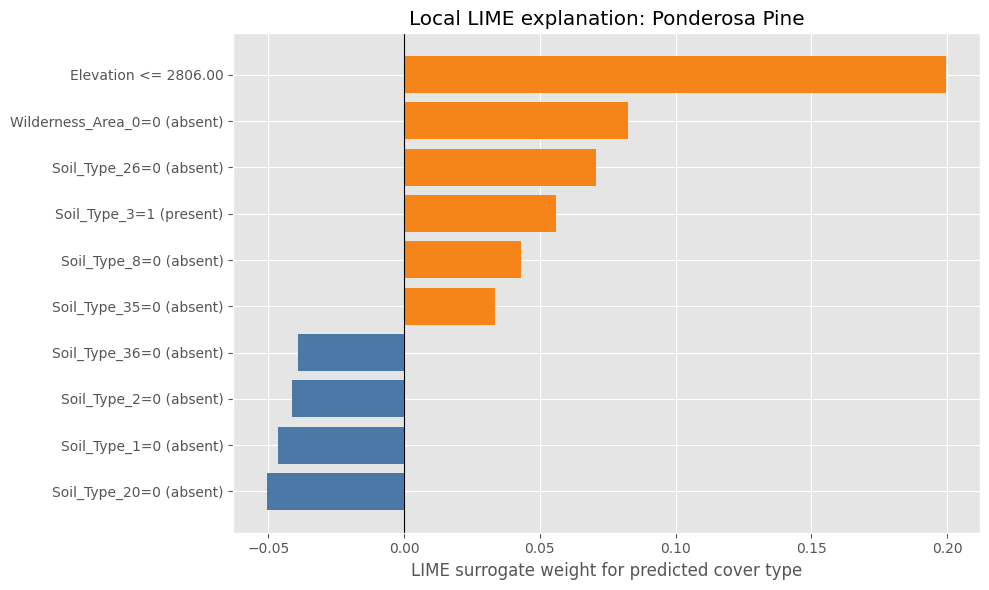

In [13]:
local_terms = explanation.as_list(label=predicted_class)
local_df = pd.DataFrame(local_terms, columns=["condition", "weight"]).sort_values("weight")
colors = ["#4C78A8" if value < 0 else "#F58518" for value in local_df.weight]
plt.figure(figsize=(10, 6))
plt.barh(local_df.condition, local_df.weight, color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("LIME surrogate weight for predicted cover type")
plt.title(f"Local LIME explanation: {class_names[predicted_class]}")
plt.tight_layout()
plt.show()


## 7. Compare local explanations for different test examples

A single case can be atypical. We explain one held-out example predicted as each cover type, when examples for that type are available. These are illustrative single-run explanations; the runtime, fidelity, and stability benchmark above uses the selected example only.


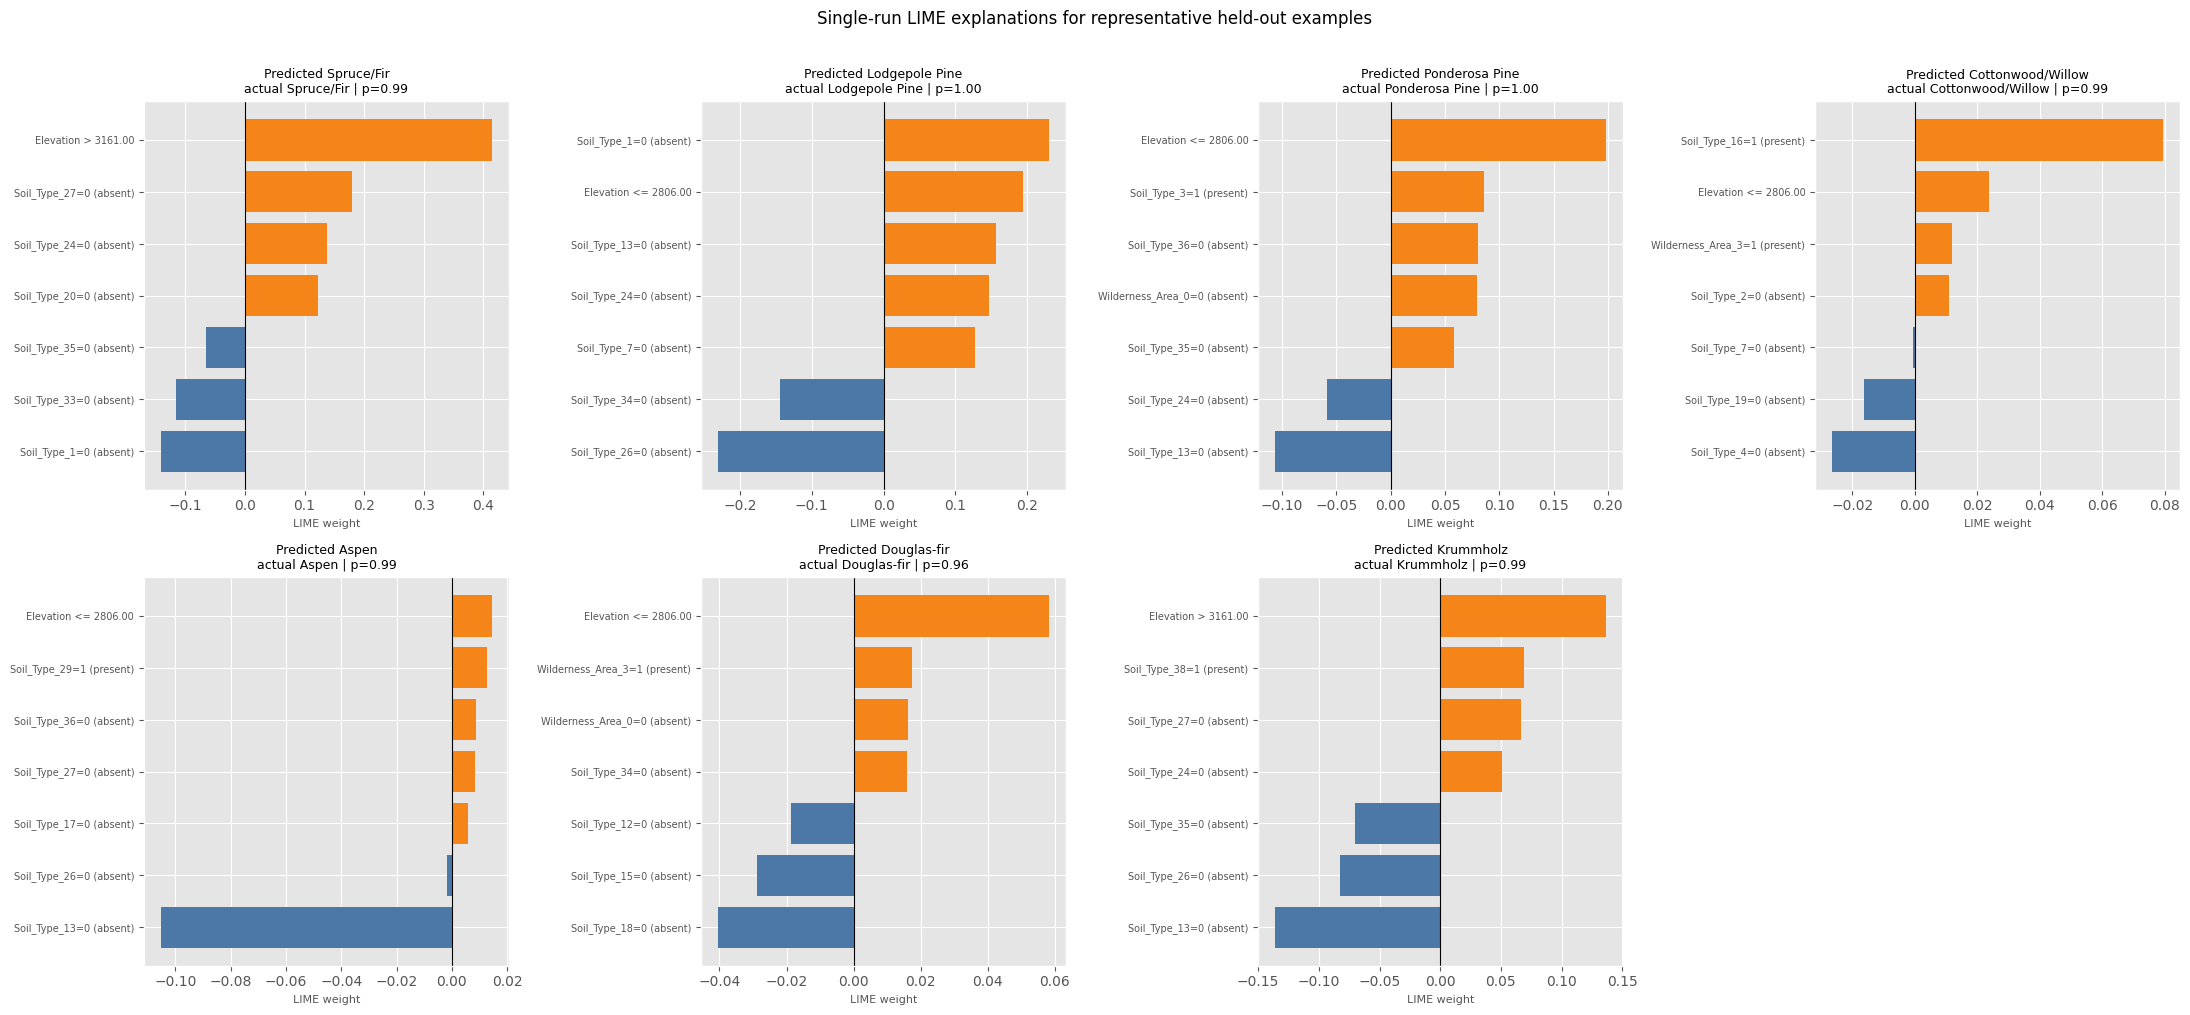

In [14]:
representatives = []
for class_id in range(len(class_names)):
    candidates = np.flatnonzero(y_pred == class_id)
    if len(candidates):
        pos = int(candidates[np.argmax(y_proba[candidates, class_id])])
        representatives.append((class_id, pos))

fig, axes = plt.subplots(2, 4, figsize=(22, 10), squeeze=False)
representative_explanations = []
for ax, (class_id, pos) in zip(axes.flat, representatives):
    exp = explainer.explain_instance(
        data_row=X_test.iloc[pos].to_numpy(),
        predict_fn=model.predict_proba,
        labels=(class_id,),
        num_features=7,
        num_samples=2_500,
    )
    representative_explanations.append(exp)
    terms = pd.DataFrame(exp.as_list(label=class_id), columns=["condition", "weight"]).sort_values("weight")
    ax.barh(terms.condition, terms.weight,
            color=["#4C78A8" if w < 0 else "#F58518" for w in terms.weight])
    ax.axvline(0, color="black", linewidth=.8)
    ax.set_title(f"Predicted {class_names[class_id]}\nactual {class_names[int(y_test.iloc[pos])]} | p={y_proba[pos, class_id]:.2f}", fontsize=9)
    ax.set_xlabel("LIME weight", fontsize=8)
    ax.tick_params(axis="y", labelsize=7)
for ax in axes.flat[len(representatives):]:
    ax.axis("off")
fig.suptitle("Single-run LIME explanations for representative held-out examples", y=1.01)
plt.tight_layout()
plt.show()


## 8. Review the benchmark results

The table below summarizes the repeated-run benchmark for the selected held-out row. Runtime covers each `explain_instance` call, including perturbation generation, model queries, and local surrogate fitting. It excludes data preparation, model training, and explainer setup. `exp.score` is LIME’s local surrogate R² score. Pairwise Spearman and top-five agreement summarize stability across the five runs at each sample budget.


,num_samples,runs,mean_runtime_seconds,sd_runtime_seconds,mean_local_fidelity_r2,sd_local_fidelity_r2,mean_pairwise_spearman,mean_top5_agreement
0,500,5,0.0102,0.0007,0.3138,0.0239,0.2575,0.34
1,1000,5,0.0149,0.0004,0.3034,0.0248,0.2795,0.50
2,2500,5,0.0298,0.0007,0.3073,0.0174,0.3440,0.48
3,5000,5,0.0549,0.0020,0.3069,0.0123,0.3741,0.54
4,10000,5,0.1025,0.0012,0.3003,0.0051,0.4283,0.60


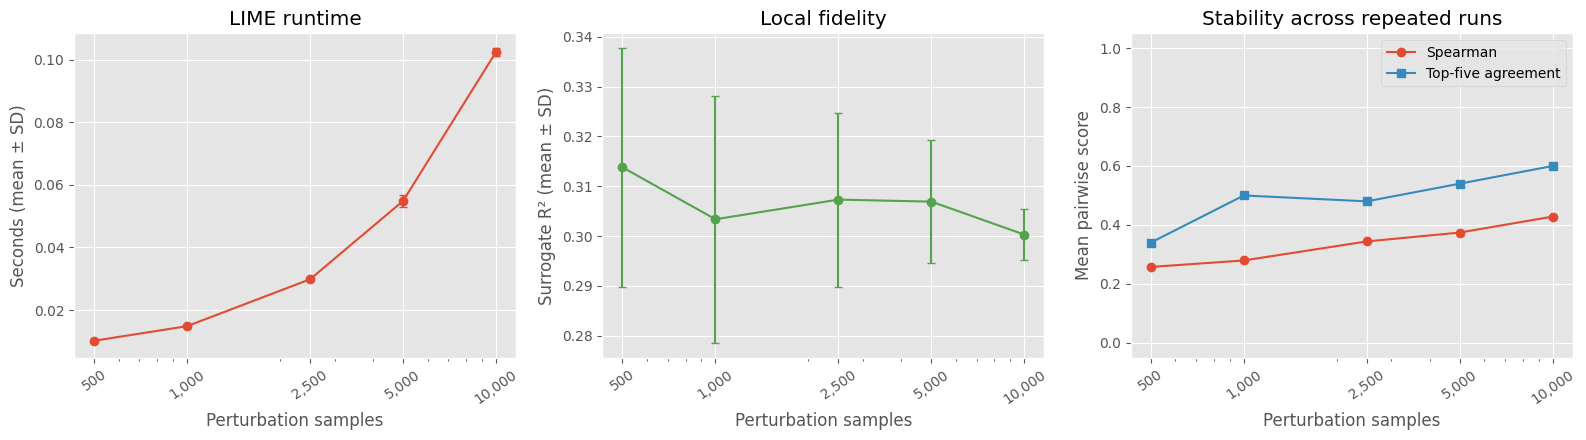

In [15]:
display(lime_benchmark_metrics.round(4))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].errorbar(lime_benchmark_metrics["num_samples"], lime_benchmark_metrics["mean_runtime_seconds"],
                 yerr=lime_benchmark_metrics["sd_runtime_seconds"], marker="o", capsize=3)
axes[0].set(title="LIME runtime", xlabel="Perturbation samples", ylabel="Seconds (mean ± SD)")
axes[0].set_xscale("log")
axes[0].set_xticks(LIME_SAMPLE_BUDGETS, labels=[f"{x:,}" for x in LIME_SAMPLE_BUDGETS])
axes[0].tick_params(axis="x", rotation=35)

axes[1].errorbar(lime_benchmark_metrics["num_samples"], lime_benchmark_metrics["mean_local_fidelity_r2"],
                 yerr=lime_benchmark_metrics["sd_local_fidelity_r2"], marker="o", capsize=3, color="#54A24B")
axes[1].set(title="Local fidelity", xlabel="Perturbation samples", ylabel="Surrogate R² (mean ± SD)")
axes[1].set_xscale("log")
axes[1].set_xticks(LIME_SAMPLE_BUDGETS, labels=[f"{x:,}" for x in LIME_SAMPLE_BUDGETS])
axes[1].tick_params(axis="x", rotation=35)

axes[2].plot(lime_benchmark_metrics["num_samples"], lime_benchmark_metrics["mean_pairwise_spearman"],
             marker="o", label="Spearman")
axes[2].plot(lime_benchmark_metrics["num_samples"], lime_benchmark_metrics["mean_top5_agreement"],
             marker="s", label="Top-five agreement")
axes[2].set(title="Stability across repeated runs", xlabel="Perturbation samples", ylabel="Mean pairwise score", ylim=(-0.05, 1.05))
axes[2].set_xscale("log")
axes[2].set_xticks(LIME_SAMPLE_BUDGETS, labels=[f"{x:,}" for x in LIME_SAMPLE_BUDGETS])
axes[2].tick_params(axis="x", rotation=35)
axes[2].legend()

plt.tight_layout()
plt.show()


## 9. How to read the measurements

Keep XGBoost's predictive performance (accuracy, precision, recall, and F1 above) separate from the LIME diagnostics. The benchmark measures one high-confidence held-out example for the predicted class shown in Section 6, using five runs at each sample budget. It does not establish behavior for every test row or other model families.

Higher `exp.score` indicates a better local fit of LIME’s surrogate to the model’s perturbed predictions. Higher pairwise Spearman and top-five agreement indicate more similar explanations across repeated runs. LIME’s perturbations can include unrealistic combinations of correlated or mutually constrained wilderness and soil indicators, which can affect fidelity.


## Dataset, objective, and measured diagnostics

Covertype contains 581,012 forest cells, each representing a 30 × 30 metre area. This notebook uses a stratified 10,000-row sample with 54 terrain, distance, hillshade, wilderness, and soil features to predict one of seven cover types.

The earlier single-row benchmark is illustrative only. The controlled benchmark below summarizes across the same fixed, stratified held-out cases, budgets, background sample, and repeat seeds used by every model. It varies LIME's perturbation dimension over 18, 36, and 54 features using shared nested subsets; excluded features stay fixed at each case's observed value. This measures explanation-space scaling, not retraining models on fewer predictors. See `controlled_lime_protocol.py`.


## Controlled LIME cost/quality comparison

The research comparison uses three fixed held-out rows per class, independent of model predictions. It reports held-out predictive metrics separately from LIME runtime, local surrogate fit, and stability. `exp.score` is not predictive accuracy. Runtime includes model calls made by LIME, but excludes explainer setup and warm-up.

In [ ]:
from IPython.display import display
from controlled_lime_protocol import benchmark_lime, evaluate_predictive_performance

model_name = "XGBoost"
predict_proba_for_lime = lambda rows: model.predict_proba(pd.DataFrame(rows, columns=X.columns))
controlled_raw, controlled_summary = benchmark_lime(
    model, X_train, X_test, y_test, predict_proba_for_lime, model_name
)
print("Held-out predictive performance:", evaluate_predictive_performance(model, X_test, y_test))
display(controlled_summary.round(4))
controlled_raw.to_csv(f"{model_name.lower()}_controlled_lime_raw.csv", index=False)
controlled_summary.to_csv(f"{model_name.lower()}_controlled_lime_summary.csv", index=False)